<a href="https://colab.research.google.com/github/Sreekar-DS/Unsupervised-ML---Myntra-Customer-Segmentation/blob/main/Colab%20Notebook/Unsupervised_ML_Online_Retail_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Machine Learning Project**  
## **Online Retail Customer Segmentation for Myntra Gifts Ltd.**

##### **Project Type** - Unsupervised Machine Learning / Customer Segmentation  
##### **Contribution** - Individual  
##### **Student Name** - Tarun Sreekar Parasa
##### **Video Presentation Link** - https://drive.google.com/file/d/1pXj9M_xgWpNe8ryVhZdLsnFh3Jfv_Aak/view?usp=sharing

# **Project Summary**

This project applies unsupervised machine learning to an online retail transaction dataset belonging to Myntra Gifts Ltd., a UK-based online giftware business. The dataset contains invoice-level transaction records with product, quantity, price, customer, date, and country information. Since there is no predefined target variable, the main objective is to discover natural customer groups based on purchasing behavior and convert those groups into practical business strategies.

The project follows a complete unsupervised learning workflow. First, exploratory data analysis is performed to understand the structure of the data, transaction period, missing values, duplicate records, cancelled invoices, product popularity, country-wise demand, order value patterns, and monthly purchasing trends. This stage helps identify issues such as missing customer IDs, negative quantities caused by cancelled transactions, skewed monetary values, and high-value outliers.

After EDA, the data is cleaned by removing records without CustomerID, cancelled invoices, non-positive quantities, non-positive prices, and duplicate rows. A total purchase amount feature is created by multiplying quantity with unit price. The transaction-level data is then transformed into a customer-level analytical dataset using RFM-style features: Recency, Frequency, Monetary value, average order value, total quantity purchased, and number of distinct products bought. These features are selected because they describe how recently a customer purchased, how often they buy, how much they spend, and how broad their product interest is.

The feature engineering stage also includes outlier handling and logarithmic transformation for highly skewed variables. Standard scaling is applied because clustering algorithms such as K-Means and hierarchical clustering are distance-based and can be strongly influenced by feature scale. Several values of K are tested using elbow and silhouette methods to estimate a suitable number of clusters. K-Means clustering is then used as the final model because it is simple, interpretable, efficient on customer-level data, and suitable for business segmentation.

Finally, clusters are visualized using PCA and profiled using median values for key customer metrics. Each cluster is interpreted in business language, such as high-value loyal customers, recent moderate customers, low-value/infrequent customers, and dormant customers. The output can help stakeholders design segment-specific strategies including retention campaigns, win-back offers, product recommendations, inventory planning, and personalized marketing.

# **Problem Statement**

Myntra Gifts Ltd. wants to better understand its customer base using historical online retail transactions. The business has invoice-level purchase data but does not have predefined customer labels such as loyal, inactive, high-value, or low-value customers. Therefore, the goal is to use unsupervised machine learning to segment customers based on purchasing behavior.

The project aims to answer the following business questions:

1. Which customer groups naturally exist in the transaction data?
2. How do customers differ in terms of recency, frequency, monetary value, quantity purchased, and product variety?
3. What is the ideal number of customer clusters?
4. How can each customer segment be interpreted for marketing, retention, inventory, and pricing strategies?

# **Business Context**

Myntra is a leading Indian fashion e-commerce company known for a wide range of clothing, accessories, and lifestyle products. In this project context, the dataset represents online retail operations for Myntra Gifts Ltd., a UK-based division specializing in unique all-occasion giftware. The data contains transactions from **01 December 2010 to 09 December 2011** and provides a detailed view of international online retail activity.

The purpose of this analysis is to extract useful business insights and build meaningful customer segments. These segments can help the company identify purchasing trends, evaluate product performance, understand customer behavior, optimize pricing strategies, and streamline inventory management.

# **Project Architecture**

The project follows this workflow:

1. **EDA** - Understand the business problem, visualize relationships, analyze product popularity, country-wise orders, and customer spending behavior.
2. **Clean-up** - Handle missing values, duplicate rows, cancelled invoices, invalid quantities, invalid prices, and outliers.
3. **Feature Engineering** - Create customer-level RFM and behavioral features.
4. **Preprocessing** - Apply outlier capping, log transformation, and feature scaling.
5. **Model Implementation** - Test the ideal number of clusters using elbow and silhouette charts, then apply K-Means clustering.
6. **Model Explainability** - Interpret how many clusters exist, explain what each cluster means, and suggest stakeholder strategies.

# **Dataset Description**

| Field | Description |
|---|---|
| InvoiceNo | Invoice number |
| StockCode | Product stock code |
| Description | Product description |
| Quantity | Quantity bought |
| InvoiceDate | Date and time of invoice |
| UnitPrice | Price per unit |
| CustomerID | Unique customer ID |
| Country | Customer/order location |

In [2]:
# ==============================
# 1. Import Libraries
# ==============================

import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
# ==============================
# 2. Data Loading Helper
# ==============================

DATA_URL = "https://drive.google.com/file/d/1spGIIVJQ-QlCjlSHnf7JwzCgkIbK8jYS/view?usp=sharing"


def convert_google_drive_url(url):
    """Convert a Google Drive sharing URL into a direct download URL."""
    if not url:
        return url
    if "drive.google.com" in url and "/file/d/" in url:
        file_id = re.search(r"/file/d/([^/]+)", url).group(1)
        return f"https://drive.google.com/uc?id={file_id}"
    return url


def load_online_retail_data(data_url=""):
    """Load the retail CSV from URL."""
    if data_url:
        url = convert_google_drive_url(data_url)
        print(f"Loading data from URL: {url}")
        return pd.read_csv(url, encoding="ISO-8859-1")

    raise ValueError("DATA_URL is empty. Please provide a Google Drive link to the CSV file.")

raw_df = load_online_retail_data(DATA_URL)
print("Dataset shape:", raw_df.shape)
raw_df.head()

Loading data from URL: https://drive.google.com/uc?id=1spGIIVJQ-QlCjlSHnf7JwzCgkIbK8jYS
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,"17,850.00",United Kingdom


In [4]:
# ==============================
# 3. Basic Data Understanding
# ==============================

display(raw_df.info())
display(raw_df.describe(include='all').T)

missing_summary = pd.DataFrame({
    'Missing_Count': raw_df.isna().sum(),
    'Missing_Percentage': (raw_df.isna().mean() * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

missing_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,218.08,"-80,995.00",1.00,3.00,10.00,"80,995.00"
InvoiceDate,541909,23260,10/31/11 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,96.76,"-11,062.06",1.25,2.08,4.13,"38,970.00"
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","1,713.60","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing_Count,Missing_Percentage
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [5]:
# Check duplicate records and cancelled invoices
print("Duplicate rows:", raw_df.duplicated().sum())
print("Cancelled invoice rows:", raw_df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Unique invoices:", raw_df['InvoiceNo'].nunique())
print("Unique products:", raw_df['StockCode'].nunique())
print("Unique customers before cleaning:", raw_df['CustomerID'].nunique())
print("Unique countries:", raw_df['Country'].nunique())

Duplicate rows: 5268
Cancelled invoice rows: 9288
Unique invoices: 25900
Unique products: 4070
Unique customers before cleaning: 4372
Unique countries: 38


In [6]:
# Convert InvoiceDate and inspect transaction period
raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'], format='%m/%d/%y %H:%M', errors='coerce')
print("Start date:", raw_df['InvoiceDate'].min())
print("End date:", raw_df['InvoiceDate'].max())

Start date: 2010-12-01 08:26:00
End date: 2011-12-09 12:50:00


# **Exploratory Data Analysis**

The EDA section explores product popularity, geographic distribution, purchasing trends, price behavior, and customer-level questions before clustering.

In [7]:
# Create a temporary sales amount for EDA
eda_df = raw_df.copy()
eda_df['TotalAmount'] = eda_df['Quantity'] * eda_df['UnitPrice']

# Exclude cancelled/negative transactions only for clean EDA visualizations
eda_positive = eda_df[
    (~eda_df['InvoiceNo'].astype(str).str.startswith('C')) &
    (eda_df['Quantity'] > 0) &
    (eda_df['UnitPrice'] > 0)
].copy()

print("Positive transaction records:", eda_positive.shape)

Positive transaction records: (530104, 9)


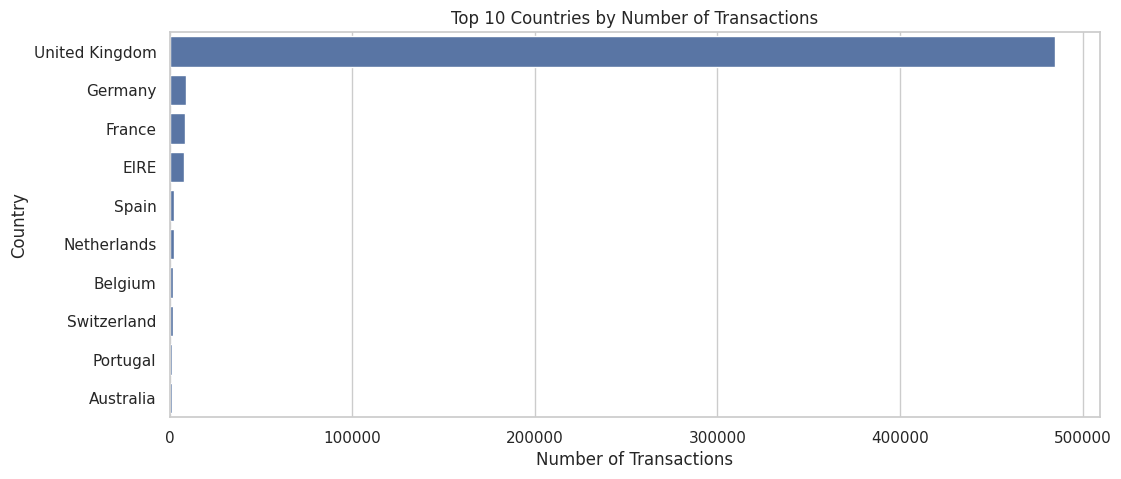

In [8]:
# Top countries by number of transactions
country_orders = eda_positive['Country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_orders.values, y=country_orders.index, color=sns.color_palette()[0])
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()

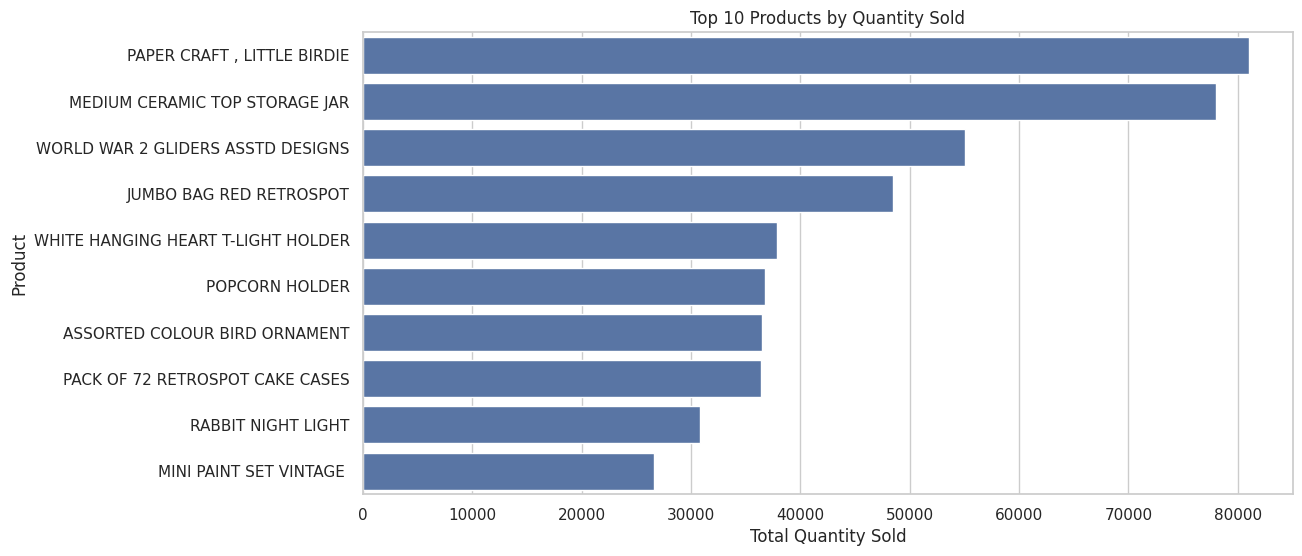

In [9]:
# Top products by quantity sold
top_products = (eda_positive.groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, color=sns.color_palette()[0])
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()

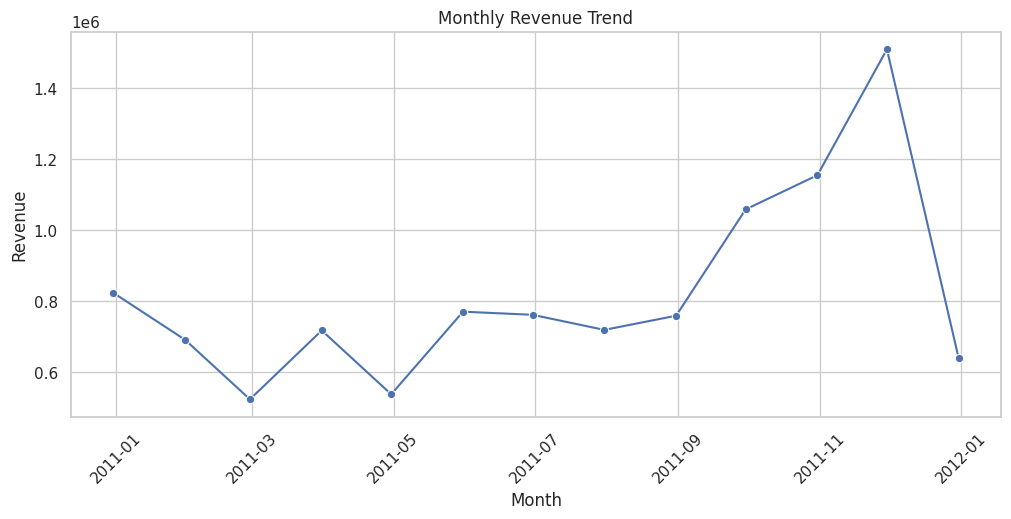

In [10]:
# Monthly revenue trend
monthly_sales = (eda_positive.set_index('InvoiceDate')
                 .resample('M')['TotalAmount']
                 .sum()
                 .reset_index())

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='InvoiceDate', y='TotalAmount', marker='o', color=sns.color_palette()[0])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

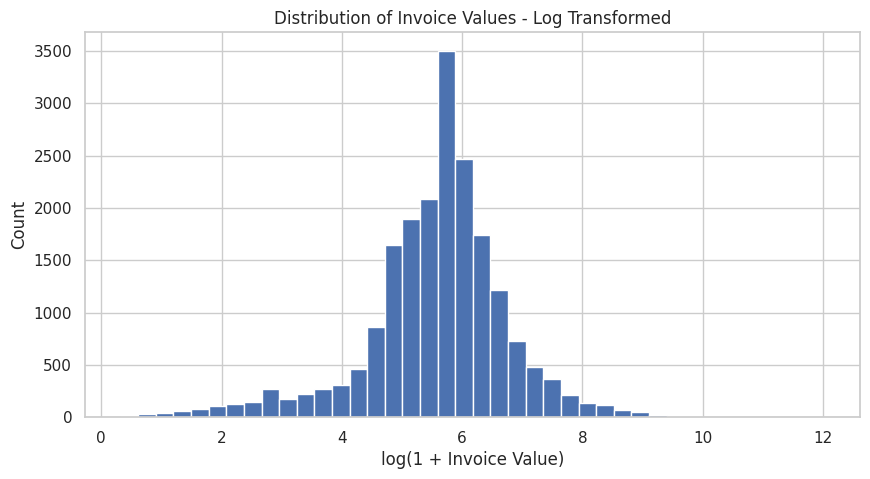

In [11]:
# Distribution of customer order values
invoice_values = (eda_positive.groupby('InvoiceNo')['TotalAmount']
                  .sum()
                  .reset_index(name='InvoiceValue'))

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(invoice_values['InvoiceValue']), bins=40)
plt.title('Distribution of Invoice Values - Log Transformed')
plt.xlabel('log(1 + Invoice Value)')
plt.ylabel('Count')
plt.show()

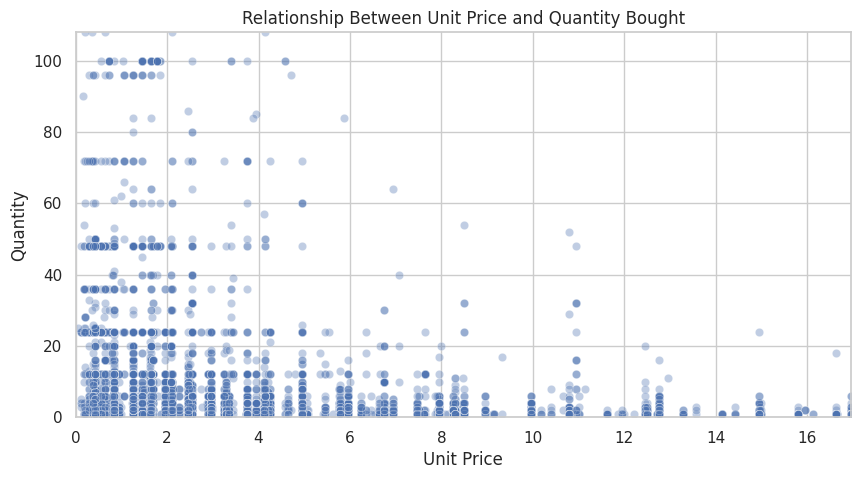

In [12]:
# Product price vs quantity relationship
sample_plot = eda_positive.sample(min(10000, len(eda_positive)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample_plot, x='UnitPrice', y='Quantity', alpha=0.35, color=sns.color_palette()[0])
plt.xlim(0, sample_plot['UnitPrice'].quantile(0.99))
plt.ylim(0, sample_plot['Quantity'].quantile(0.99))
plt.title('Relationship Between Unit Price and Quantity Bought')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.show()

## **EDA Observations**

1. Most transactions are concentrated in the United Kingdom, but the dataset includes multiple international countries.
2. Product demand is uneven, with a small number of products contributing heavily to quantity sold.
3. Invoice values are highly right-skewed, meaning most orders are small or moderate while a few orders are very large.
4. The presence of cancelled invoices, negative quantities, missing CustomerID values, and duplicate rows makes cleaning essential before customer segmentation.
5. Since clustering should happen at customer level, transaction-level data must be aggregated into meaningful customer-level features.

# **Data Cleaning**

In [13]:
df = raw_df.copy()

# Step 1: Group by InvoiceNo and count the number of CustomerIDs for each invoice.
# This counts all CustomerID entries, including NaNs if they were present.
invoice_customer_counts = df.groupby('InvoiceNo')['CustomerID'].count()

print("Counts of CustomerIDs per InvoiceNo (first 5):")
display(invoice_customer_counts.head())

# Step 2: Identify InvoiceNo values where the CustomerID count is exactly 1.
invoices_with_single_customer_count = invoice_customer_counts[invoice_customer_counts == 0].index

print(f"\nNumber of Invoices with exactly one CustomerID record: {len(invoices_with_single_customer_count)}")

# Step 3: Filter the original DataFrame 'df' to keep only the rows belonging to these invoices.
filtered_df_by_invoice_customer_count = df[df['InvoiceNo'].isin(invoices_with_single_customer_count)]

print("\nShape of DataFrame containing only invoices with exactly one CustomerID record:", filtered_df_by_invoice_customer_count.shape)
display(filtered_df_by_invoice_customer_count)

Counts of CustomerIDs per InvoiceNo (first 5):


,CustomerID
InvoiceNo,
536365,7
536366,2
536367,12
536368,4
536369,1



Number of Invoices with exactly one CustomerID record: 3710

Shape of DataFrame containing only invoices with exactly one CustomerID record: (135080, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [14]:
# ==============================
# 4. Data Cleaning
# ==============================

df = raw_df.copy()

initial_shape = df.shape

# --- CustomerID handling modification ---
# Count initial missing CustomerIDs
missing_customer_rows_initial = df['CustomerID'].isna().sum()

# Attempt to fill missing CustomerIDs using other entries for the same InvoiceNo
# For each InvoiceNo group, if there's at least one non-null CustomerID, use the first one to fill NaNs.
# If an InvoiceNo group contains only NaNs for CustomerID, they will remain NaN.
df['CustomerID'] = df.groupby('InvoiceNo')['CustomerID'].transform(
    lambda x: x.fillna(x.dropna().iloc[0]) if not x.dropna().empty else x
)

# Count how many CustomerIDs were successfully filled
customer_ids_filled = missing_customer_rows_initial - df['CustomerID'].isna().sum()

# Count how many CustomerIDs are still missing after the fill attempt
missing_customer_rows_after_fill_attempt = df['CustomerID'].isna().sum()

# Remove any remaining records without CustomerID (those that couldn't be filled)
df.dropna(subset=['CustomerID'], inplace=True)
# --- End CustomerID handling modification ---

# Store current row count for subsequent removal calculations
current_rows = df.shape[0]

# Remove cancelled invoices
cancelled_rows_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantities and prices
invalid_quantity_rows_count = (df['Quantity'] <= 0).sum() # Count rows with invalid quantity BEFORE removal
invalid_price_rows_count = (df['UnitPrice'] <= 0).sum()   # Count rows with invalid price BEFORE removal
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove duplicate rows
duplicate_rows_count = df.duplicated().sum()
df = df.drop_duplicates()

# Convert CustomerID to string-like ID
# It is an identifier, not a numeric measurement.
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# Create total sales amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

cleaning_report = pd.DataFrame({
    'Step': [
        'Initial rows',
        'Missing CustomerID (initial count)',
        'CustomerID filled by InvoiceNo',
        'Remaining missing CustomerID removed', # Rows that were still NaN after fill and then dropped
        'Cancelled invoices removed',
        'Invalid quantity rows removed',
        'Invalid price rows removed',
        'Duplicate rows removed',
        'Final clean rows'
    ],
    'Count': [
        initial_shape[0],
        missing_customer_rows_initial,
        customer_ids_filled,
        missing_customer_rows_after_fill_attempt,
        cancelled_rows_count,
        invalid_quantity_rows_count,
        invalid_price_rows_count,
        duplicate_rows_count,
        df.shape[0]
    ]
})

cleaning_report

,Step,Count
0,Initial rows,541909
1,Missing CustomerID (initial count),135080
2,CustomerID filled by InvoiceNo,0
3,Remaining missing CustomerID removed,135080
4,Cancelled invoices removed,8905
5,Invalid quantity rows removed,0
6,Invalid price rows removed,40
7,Duplicate rows removed,5192
8,Final clean rows,392692


In [15]:
print("Cleaned dataset shape:", df.shape)
print("Unique customers after cleaning:", df['CustomerID'].nunique())
print("Unique invoices after cleaning:", df['InvoiceNo'].nunique())
print("Total revenue after cleaning:", round(df['TotalAmount'].sum(), 2))
df.head()

Cleaned dataset shape: (392692, 9)
Unique customers after cleaning: 4338
Unique invoices after cleaning: 18532
Total revenue after cleaning: 8887208.89


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# **Feature Engineering**

The transaction data is converted into a customer-level dataset. This is necessary because the business question is about customer segmentation, not transaction segmentation.

Created features:

- **Recency**: Number of days since the customer's last purchase.
- **Frequency**: Number of unique invoices/orders.
- **Monetary**: Total amount spent by the customer.
- **AvgOrderValue**: Average transaction line value.
- **Quantity**: Total quantity purchased.
- **DistinctProducts**: Number of unique products purchased.
- **Country**: Customer's most common country in the records.

In [16]:
# ==============================
# 5. Customer-Level Feature Engineering
# ==============================

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = (df.groupby('CustomerID')
               .agg(
                   LastPurchaseDate=('InvoiceDate', 'max'),
                   Frequency=('InvoiceNo', 'nunique'),
                   Monetary=('TotalAmount', 'sum'),
                   AvgOrderValue=('TotalAmount', 'mean'),
                   Quantity=('Quantity', 'sum'),
                   DistinctProducts=('StockCode', 'nunique'),
                   Country=('Country', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
               )
               .reset_index())

customer_df['Recency'] = (reference_date - customer_df['LastPurchaseDate']).dt.days

# Reorder columns
customer_df = customer_df[['CustomerID', 'Country', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Quantity', 'DistinctProducts']]

print("Customer-level dataset shape:", customer_df.shape)
customer_df.head()

Customer-level dataset shape: (4338, 9)


,CustomerID,Country,LastPurchaseDate,Recency,Frequency,Monetary,AvgOrderValue,Quantity,DistinctProducts
0,12346,United Kingdom,2011-01-18 10:01:00,326,1,"77,183.60","77,183.60",74215,1
1,12347,Iceland,2011-12-07 15:52:00,2,7,"4,310.00",23.68,2458,103
2,12348,Finland,2011-09-25 13:13:00,75,4,"1,797.24",57.98,2341,22
3,12349,Italy,2011-11-21 09:51:00,19,1,"1,757.55",24.08,631,73
4,12350,Norway,2011-02-02 16:01:00,310,1,334.40,19.67,197,17


In [17]:
customer_df[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Quantity', 'DistinctProducts']].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02"
AvgOrderValue,"4,338.00",68.38,"1,467.92",2.14,12.39,17.76,24.88,"77,183.60"
Quantity,"4,338.00","1,187.64","5,043.62",1.00,159.00,378.00,989.75,"196,915.00"
DistinctProducts,"4,338.00",61.50,85.37,1.00,16.00,35.00,77.00,"1,787.00"


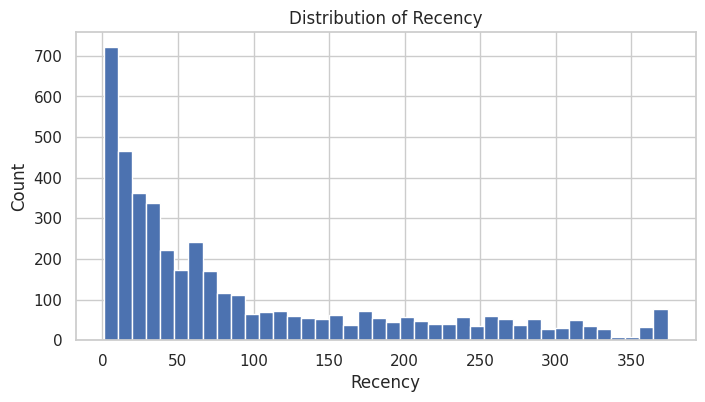

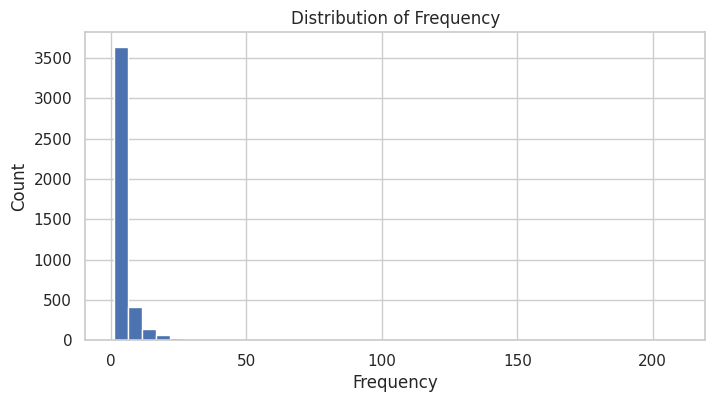

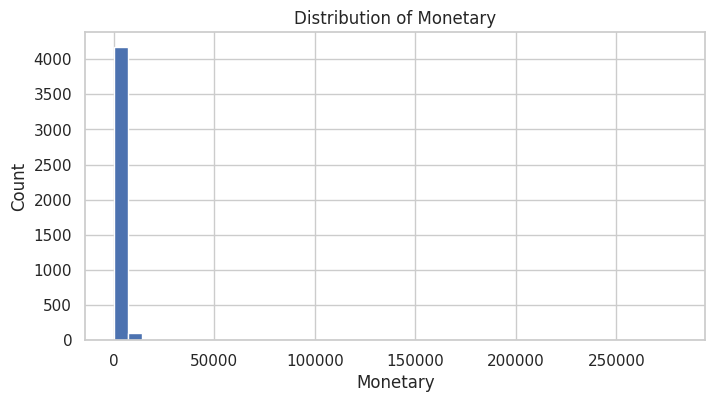

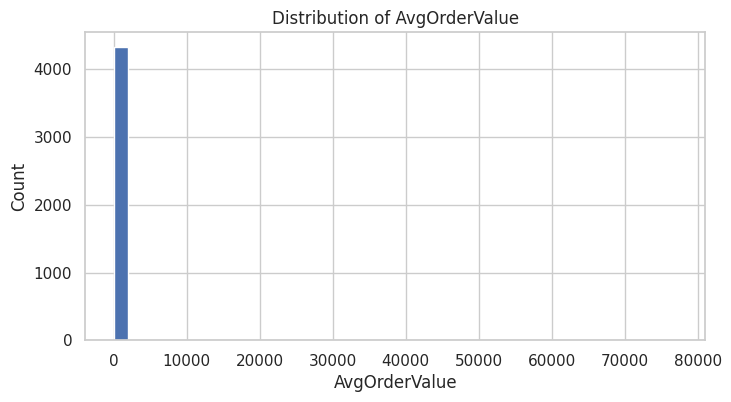

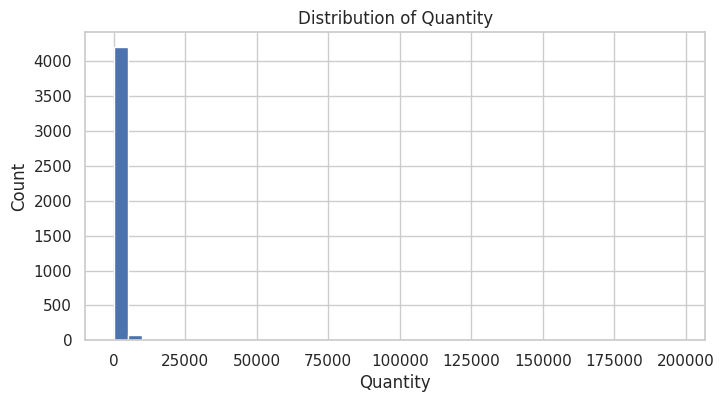

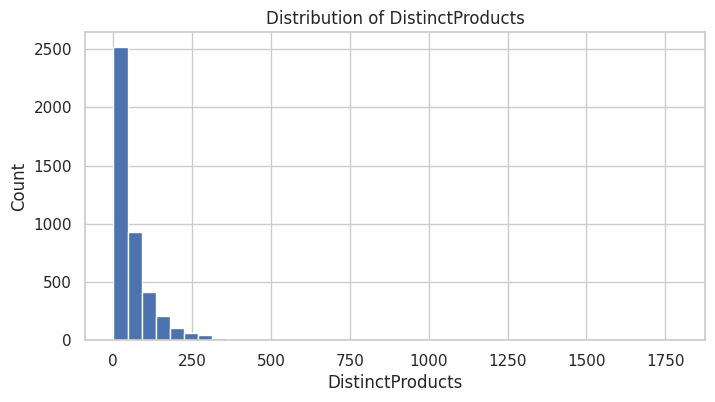

In [18]:
# Visualize feature distributions before transformation
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Quantity', 'DistinctProducts']

for col in feature_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(customer_df[col], bins=40)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# **Preprocessing**

RFM-style retail features are usually skewed because a small percentage of customers may place very large orders or purchase very frequently. To reduce the effect of extreme outliers while preserving customer ranking, the features are capped at the 1st and 99th percentiles. Log transformation is then applied to positively skewed spending and activity variables. Finally, the features are standardized.

In [19]:
# ==============================
# 6. Preprocessing
# ==============================

cluster_features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Quantity', 'DistinctProducts']
X = customer_df[cluster_features].copy()

# Outlier capping at 1st and 99th percentiles
for col in cluster_features:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(lower, upper)

# Log transform skewed positive features except Recency
log_transform_cols = ['Frequency', 'Monetary', 'AvgOrderValue', 'Quantity', 'DistinctProducts']
for col in log_transform_cols:
    X[col] = np.log1p(X[col])

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

processed_df = pd.DataFrame(X_scaled, columns=cluster_features)
processed_df.head()

,Recency,Frequency,Monetary,AvgOrderValue,Quantity,DistinctProducts
0,2.34,-0.97,2.72,3.64,2.53,-2.54
1,-0.91,1.11,1.47,0.28,1.39,0.98
2,-0.18,0.40,0.75,1.36,1.35,-0.37
3,-0.74,-0.97,0.73,0.30,0.36,0.67
4,2.18,-0.97,-0.63,0.06,-0.53,-0.59


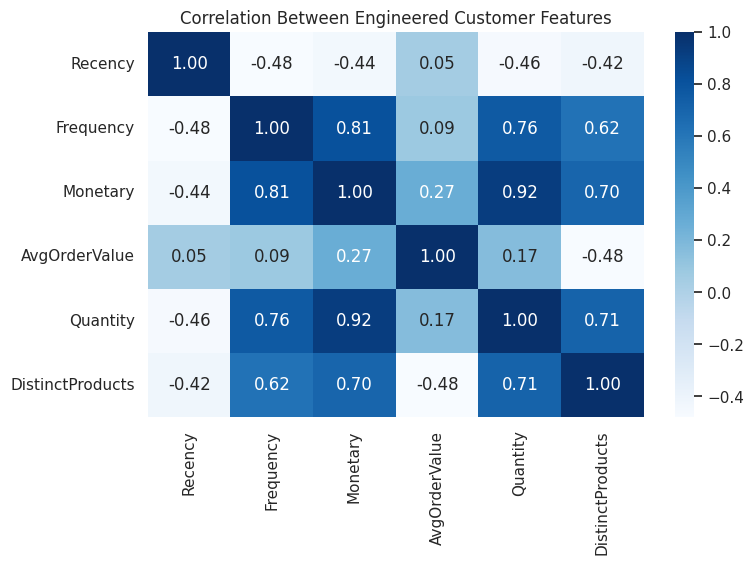

In [20]:
# Correlation after preprocessing
plt.figure(figsize=(8, 5))
sns.heatmap(pd.DataFrame(X, columns=cluster_features).corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Engineered Customer Features')
plt.show()

# **Model Implementation**

Because the problem has no target variable, clustering models are used. K-Means is selected as the final approach because it is efficient, interpretable, and commonly used for customer segmentation. The ideal number of clusters is evaluated using elbow and silhouette scores.

In [21]:
# ==============================
# 7. K-Means: Elbow and Silhouette Analysis
# ==============================

k_values = range(2, 9)
inertias = []
silhouette_scores = []
davies_scores = []
calinski_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled)), random_state=42))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))

cluster_eval = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertias,
    'Silhouette_Score': silhouette_scores,
    'Davies_Bouldin_Index': davies_scores,
    'Calinski_Harabasz_Index': calinski_scores
})

cluster_eval

,K,Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index
0,2,"15,562.22",0.33,1.09,"2,916.02"
1,3,"12,526.91",0.26,1.29,"2,336.08"
2,4,"10,730.85",0.28,1.15,"2,059.42"
3,5,"9,225.52",0.25,1.16,"1,972.93"
4,6,"8,384.21",0.24,1.17,"1,823.26"
5,7,"7,547.58",0.25,1.17,"1,767.43"
6,8,"6,937.15",0.25,1.16,"1,702.29"


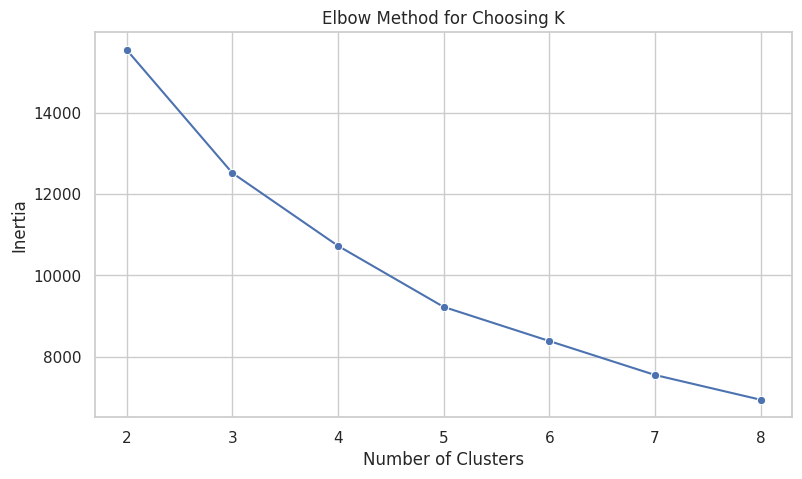

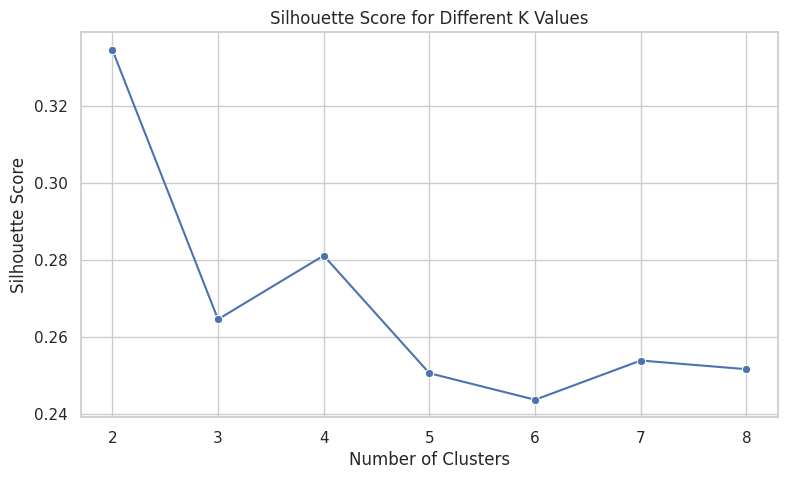

In [22]:
# Elbow chart
plt.figure(figsize=(9, 5))
sns.lineplot(data=cluster_eval, x='K', y='Inertia', marker='o', color=sns.color_palette()[0])
plt.title('Elbow Method for Choosing K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Silhouette chart
plt.figure(figsize=(9, 5))
sns.lineplot(data=cluster_eval, x='K', y='Silhouette_Score', marker='o', color=sns.color_palette()[0])
plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

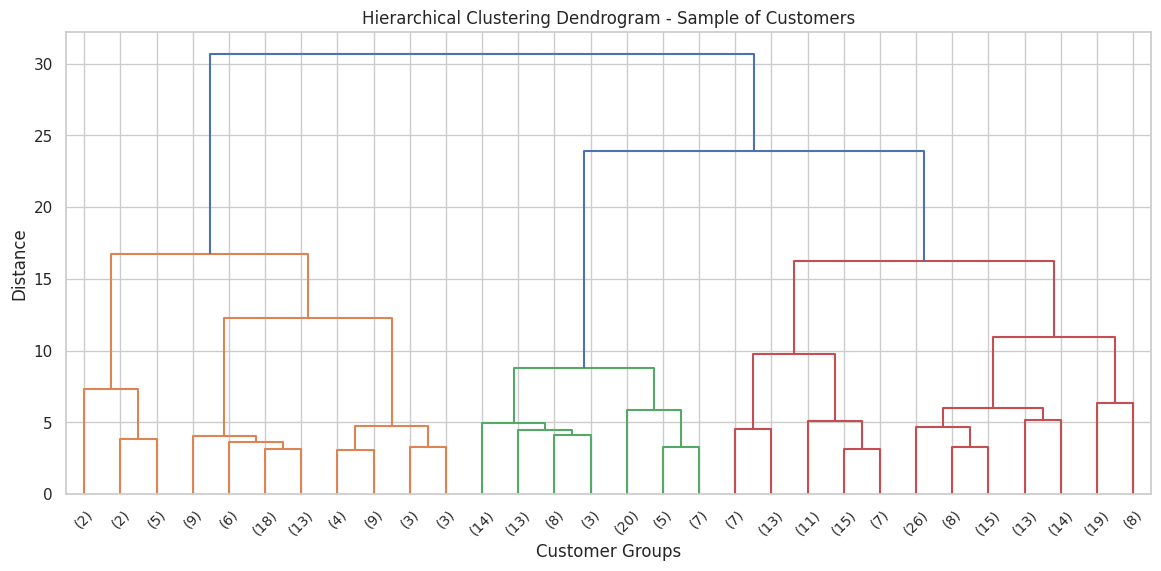

In [23]:
# Hierarchical clustering dendrogram on a sample
sample_size = min(300, len(X_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram - Sample of Customers')
plt.xlabel('Customer Groups')
plt.ylabel('Distance')
plt.show()

## **Choosing the Final Number of Clusters**

The elbow chart helps identify where the reduction in inertia starts slowing down. The silhouette chart helps evaluate how well-separated the clusters are. In business segmentation, the selected K should be both statistically reasonable and easy for stakeholders to interpret.

For this project, **K = 4** is selected as the final number of clusters because it gives a practical balance between separation and business interpretability.

In [24]:
# ==============================
# 8. Final K-Means Model
# ==============================

FINAL_K = 4
final_kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10, max_iter=300)
customer_df['Cluster'] = final_kmeans.fit_predict(X_scaled)

print("Final model silhouette score:", round(silhouette_score(X_scaled, customer_df['Cluster'], sample_size=min(2000, len(X_scaled)), random_state=42), 3))
print("Final model Davies-Bouldin index:", round(davies_bouldin_score(X_scaled, customer_df['Cluster']), 3))
print("Final model Calinski-Harabasz index:", round(calinski_harabasz_score(X_scaled, customer_df['Cluster']), 3))

customer_df.head()

Final model silhouette score: 0.281
Final model Davies-Bouldin index: 1.154
Final model Calinski-Harabasz index: 2059.42


,CustomerID,Country,LastPurchaseDate,Recency,Frequency,Monetary,AvgOrderValue,Quantity,DistinctProducts,Cluster
0,12346,United Kingdom,2011-01-18 10:01:00,326,1,"77,183.60","77,183.60",74215,1,3
1,12347,Iceland,2011-12-07 15:52:00,2,7,"4,310.00",23.68,2458,103,2
2,12348,Finland,2011-09-25 13:13:00,75,4,"1,797.24",57.98,2341,22,3
3,12349,Italy,2011-11-21 09:51:00,19,1,"1,757.55",24.08,631,73,0
4,12350,Norway,2011-02-02 16:01:00,310,1,334.40,19.67,197,17,1


In [25]:
# Cluster sizes
cluster_size = customer_df['Cluster'].value_counts().sort_index().reset_index()
cluster_size.columns = ['Cluster', 'Customer_Count']
cluster_size['Customer_Percentage'] = (cluster_size['Customer_Count'] / cluster_size['Customer_Count'].sum() * 100).round(2)
cluster_size

,Cluster,Customer_Count,Customer_Percentage
0,0,1725,39.76
1,1,1056,24.34
2,2,1198,27.62
3,3,359,8.28


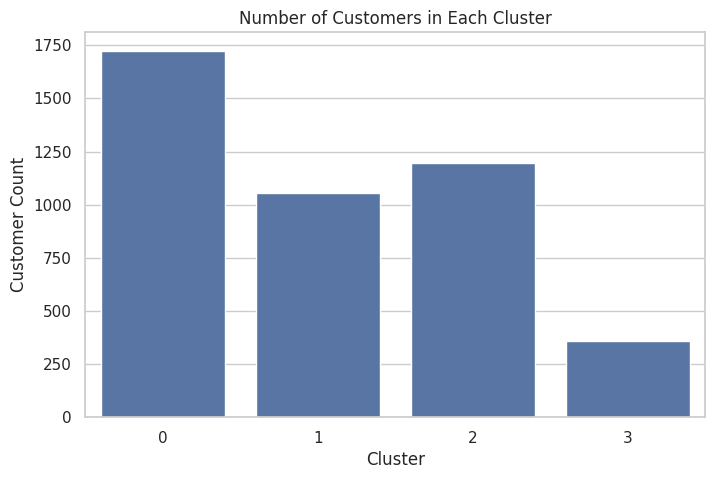

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_size, x='Cluster', y='Customer_Count', color=sns.color_palette()[0])
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.show()